# Programming Principles for AI
## Lecture 4: Search, IDEs, AI-Assisted Programming and AI Applications

In this lesson we will learn how to use data structures to explore search spaces, how to use IDEs and AI-assisted programming to make development easier, and how to develop simple AI applications.

---
## Quick recap

We have used variables, lists, dictionaries, conditions, loops, and functions. We have also worked with tabular data using pandas.

The following function combines several of these ideas. It receives a list of customer requests and returns the IDs of the requests that are still open.

**Before running it:** What will be printed? What does `return` do?


In [ ]:
requests = [
    {"id": "R1", "status": "open"},
    {"id": "R2", "status": "closed"},
    {"id": "R3", "status": "open"}
]

def get_open_requests(requests):
    open_ids = []
    for request in requests:
        if request["status"] == "open":
            open_ids.append(request["id"])
    return open_ids

print(get_open_requests(requests))


### A small change

Add an open request with ID `R4` to `requests`, then call the function again.

Does the function need to change when the number of requests changes?


In [ ]:
# Add the new request and print the result here.
# If you run your solution more than once, remember that append() adds another item.


---

## **Stacks**

Suppose an editor keeps a history of your actions. When you click **Undo**, it should undo the most recent action first.

A **stack** follows this rule: **Last In, First Out (LIFO)**.

We can use a Python list as a stack:

- `append(item)` adds an item at the end, also called pushing.
- `pop()` removes and returns the last item, also called popping.

**Predict:** Which action will be undone first?


In [ ]:
history = [] # Your stack (it is a list. but we will only use stack-related functions on it)
history.append("Write the title")
history.append("Add a paragraph")
history.append("Insert an image")

# let's see what's in our stack
print("History:", history)

# removing the last item in the stack
last_action = history.pop()

# check the element that was removed
print("Undo:", last_action)

# let's see what's in our stack now
print("Remaining history:", history)


History: ['Write the title', 'Add a paragraph', 'Insert an image']
Undo: Insert an image
Remaining history: ['Write the title', 'Add a paragraph']


### Example/Exercise

`while history:` repeats while the list contains at least one item. An empty list is treated as false in a condition.

**Predict:** In what order will the actions be undone?


In [ ]:
history = ["Write the title", "Add a paragraph", "Insert an image"]

while history:
    action = history.pop()
    print("Undo:", action)

print("Remaining history:", history)


Undo: Insert an image
Undo: Add a paragraph
Undo: Write the title
Remaining history: []


`pop()` on an empty stack raises an error. The loop above checks that an item exists before removing it.

### **Question:** Would a stack be a good choice for serving customers in arrival order?

---

## **Queues**

Suppose customer requests should be processed in the order they arrive.

A **queue** follows this rule: **First In, First Out (FIFO)**.

We can make a list behave as a **queue** in python using:
- `append(item)` adds an item at the right end.
- `pop(0)` removes and returns the item at the left end.

**Predict:** Which request will be processed first?

In [ ]:
pending_requests = []
pending_requests.append("R1")
pending_requests.append("R2")
pending_requests.append("R3")

print("Pending requests:", pending_requests)
next_request = pending_requests.pop(0)
print("Process:", next_request)
print("Remaining requests:", pending_requests)


Pending requests: ['R1', 'R2', 'R3']
Process: R1
Remaining requests: ['R2', 'R3']


Python provides `deque` in the standard library's `collections` module.

- `append(item)` adds an item at the right end.
- `popleft()` removes and returns the item at the left end.

**Predict:** Is the following code equivalent to the previous one?

In [ ]:
from collections import deque

pending_requests = deque()
pending_requests.append("R1")
pending_requests.append("R2")
pending_requests.append("R3")

print("Pending requests:", list(pending_requests))
next_request = pending_requests.popleft()
print("Process:", next_request)
print("Remaining requests:", list(pending_requests))


Pending requests: ['R1', 'R2', 'R3']
Process: R1
Remaining requests: ['R2', 'R3']


A list can also remove its first item with `pop(0)`, but the remaining items must shift position. A `deque` is designed for efficient removal at either end.

### Processing everything in a queue

**Example/Exercise:** What will the following code do?


In [ ]:
pending_requests = deque(["R1", "R2", "R3"])

while pending_requests:
    request_id = pending_requests.popleft()
    print("Process:", request_id)


**Discussion:** Which structure would you choose for a printer that processes jobs in submission order?


---
## From data structures to search

Imagine that we need to explore a hierarchy of folders, categories, or decisions.

A **tree** represents a hierarchy:

- The **root** is the starting item at the top.
- A **node** is an item in the tree.
- A node can have **children**, the items directly below it.
- A node with no children is called a **leaf**.

In our example, `A` is the root. Its children are `B` and `C`. The children of `B` are `D` and `E`, and the children of `C` are `F` and `G`.

Each node other than the root has exactly one parent, and there are no connections back to earlier nodes. We will always explore downward, from parents to children.

Run the next cell to display the tree. The drawing code is provided; you do not need to study it.


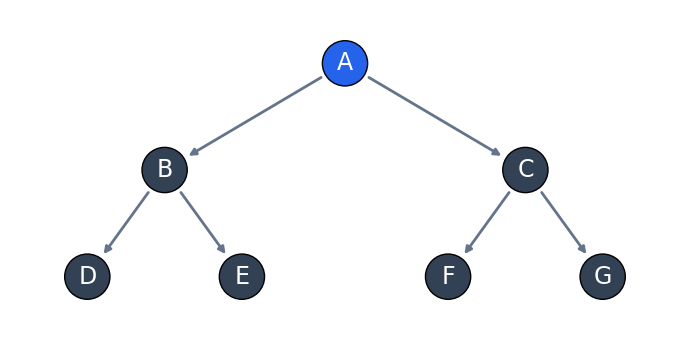

In [ ]:
#@title Display the example tree (Code is not part of the example)
import matplotlib.pyplot as plt

positions = {
    "A": (0, 2), "B": (-1.4, 1), "C": (1.4, 1),
    "D": (-2, 0), "E": (-0.8, 0), "F": (0.8, 0), "G": (2, 0)
}
connections = [("A", "B"), ("A", "C"), ("B", "D"),
               ("B", "E"), ("C", "F"), ("C", "G")]

fig, ax = plt.subplots(figsize=(7, 3.5))
for parent, child in connections:
    ax.annotate("", xy=positions[child], xytext=positions[parent],
                arrowprops={"arrowstyle": "-|>", "color": "#64748b",
                            "lw": 2, "shrinkA": 20, "shrinkB": 20})
for node, (x, y) in positions.items():
    ax.text(x, y, node, ha="center", va="center", fontsize=17,
            color="white", bbox={"boxstyle": "circle,pad=0.45",
                                 "fc": "#2563eb" if node == "A" else "#334155"})
ax.set(xlim=(-2.6, 2.6), ylim=(-0.5, 2.5))
ax.axis("off")
fig.tight_layout()
plt.show()


#### Initializing a tree-like structure

In [ ]:
# Each key is a node. Its value is a list of that node's children.
tree = {
    "A": ["B", "C"],
    "B": ["D", "E"],
    "C": ["F", "G"],
    "D": [],
    "E": [],
    "F": [],
    "G": []
}

print("Children of A:", tree["A"])
print("Children of B:", tree["B"])


Children of A: ['B', 'C']
Children of B: ['D', 'E']


An empty list means that the node has no children. For example, `D` is a leaf.

There are several ways to choose which node to explore next. We will compare two:

- **Breadth-first search (BFS):** use a queue to explore the tree level by level.
- **Depth-first search (DFS):** use a stack to follow one branch deeply before returning to pending alternatives.

Because each child has only one parent and we only move downward, each node is reached once. We do not need to keep a separate collection of visited nodes.

The goal here is to understand the behavior and read the code. You do not need to memorize either implementation.


### Breadth-first search with a queue

Start with `A` in the queue. Each time we remove a node, we add its children to the end of the queue.

We will use a regular list as the queue: `append()` adds at the end, and `pop(0)` removes from the beginning.

**Predict:** After `A`, will we explore `B` and `C`, or immediately go deeper to `D`?


In [ ]:
def breadth_first_search(tree, start):
    pending = [start]
    order = []
    while pending:
        node = pending.pop(0)  # Queue: remove the first item.
        order.append(node)
        for child in tree[node]:
            pending.append(child)
    return order

bfs_order = breadth_first_search(tree, "A")
print("BFS order:", bfs_order)


BFS order: ['A', 'B', 'C', 'D', 'E', 'F', 'G']


### Trace the queue

The leftmost item is removed next. The table shows the queue **after** processing each node and adding its children.

| Node processed | Pending queue |
|---|---|
| Before starting | `A` |
| `A` | `B, C` |
| `B` | `C, D, E` |
| `C` | `D, E, F, G` |
| `D` | `E, F, G` |
| `E` | `F, G` |
| `F` | `G` |
| `G` | Empty |

BFS explores this tree level by level: `A`, then `B` and `C`, then `D`, `E`, `F`, and `G`.


### Depth-first search with a stack

Use `pop()` instead of `pop(0)` to remove the most recently added node.

To explore the tree from left to right, we also add the children in reverse order with `reversed(tree[node])`. This puts the leftmost child at the top of the stack.

**Predict:** If we add `C` and then `B` to the stack, which one will `pop()` remove next?


In [ ]:
def depth_first_search(tree, start):
    pending = [start]
    order = []
    while pending:
        node = pending.pop()  # Stack: remove the last item.
        order.append(node)
        # Reverse children to make sure the leftmost child is at the top of the stack
        for child in reversed(tree[node]):
            pending.append(child)
    return order

dfs_order = depth_first_search(tree, "A")
print("DFS order (Left-to-Right):", dfs_order)

DFS order (Left-to-Right): ['A', 'B', 'D', 'E', 'C', 'F', 'G']


### Trace the stack

The rightmost item is removed next. Again, the table shows the pending items after processing each node.

| Node processed | Pending stack |
|---|---|
| Before starting | `A` |
| `A` | `C, B` |
| `B` | `C, E, D` |
| `D` | `C, E` |
| `E` | `C` |
| `C` | `G, F` |
| `F` | `G` |
| `G` | Empty |

This DFS explores the branch through `B` before moving to `C`. We add the children in reverse order, so `C` is added first and `B` is added last. Since the stack removes the last item added, it explores `B` first. The same rule makes it explore `D` before `E` and `F` before `G`, producing a left-to-right exploration.


### Compare the behavior

Both functions receive the same tree and starting node. Both return the nodes explored, in their exploration order.

The queue removes the first pending item with `pop(0)`, while the stack removes the last pending item with `pop()`. Our DFS also adds the children in reverse order so that it explores each branch from left to right.


In [ ]:
print("Using a queue:", breadth_first_search(tree, "A"))
print("Using a stack:", depth_first_search(tree, "A"))


Using a queue: ['A', 'B', 'C', 'D', 'E', 'F', 'G']
Using a stack: ['A', 'C', 'G', 'F', 'B', 'E', 'D']


**Questions:**

1. Which line changes the choice of the next node?
2. Why does BFS explore `B` and `C` before their children?
3. Why does this DFS explore `D` before `E`?
4. If the children of `A` were listed as `["C", "B"]`, which branch would DFS explore first?

BFS is useful when we want to explore items by level. DFS is useful when we want to explore one branch before moving to another.

These functions return the complete exploration order. They do not yet look for a particular target or stop when they find one.


### **Short exercise**: choose, predict, and verify

### Part A: Stack or queue?

Choose a structure for each task and explain your choice:

1. Undoing the most recent change in a document.
2. Serving requests in arrival order.
3. Exploring all nodes one level below the root before nodes two levels below it.

### Part B: A new starting point

Predict the BFS and DFS orders when the starting node is `B`. Then call both functions to check your predictions.

We only follow parent-to-child connections. Starting at `B` explores the smaller tree rooted at `B`, so it will not reach `A` or the branch through `C`.


In [ ]:
# Call both search functions starting from B and print their results.


### **Optional challenge**: a deeper branch

In the tree below, `D` now has two children: `H` and `I`. All other children remain the same.

1. Predict the BFS and DFS orders starting from `A`.
2. Call both functions and compare the results with your predictions.
3. Does BFS process `H` and `I` before or after all the nodes on the level above them?
4. Starting at `B`, how does the stack make DFS reach the new level?

If you use an AI assistant, ask it to trace `pending` one step at a time. Check its explanation against the program's output.


In [ ]:
tree_with_extra_level = {
    "A": ["B", "C"],
    "B": ["D", "E"],
    "C": ["F", "G"],
    "D": ["H", "I"],
    "E": [],
    "F": [],
    "G": [],
    "H": [],
    "I": []
}

# Call both search functions using tree_with_extra_level and starting from A.


## From a notebook to a Python project

The functions we wrote can also live in a `.py` file. We can run that file locally, set a breakpoint, and inspect `pending`, `node`, and `order` as the program executes.

**Next live activity:** Move the tree and search functions to VS Code. We will choose a Python interpreter, run the program, and use the debugger to follow the queue or stack one step at a time.

Remember: notebooks retain variables from earlier executions. A Python script starts with a fresh state each time you run it. Make sure the tree definition and functions appear before the calls that use them.



---
---

## AI applications in Colab and VS Code

The following examples can run in Colab. You can also move their Python code into files and execute them in VS Code.

If your local setup is not ready, continue here in Colab. The learning goals and core program logic are the same.


---
---


## Calling an LLM from Python

In Lesson 1 we called Gemini from a Python program. An **API**, or Application Programming Interface, lets our program send a request to an external service and receive a response.

We will reuse that example, then improve how it behaves when a request fails.

**Main demonstration:** approximately 10–15 minutes. The fallback exercise and offline checks can also be used as optional practice.

The workflow is: create a client, build a prompt, send the request, and inspect the response.


### Install and import the library

Run the installation cell once in Colab. In a local project, use `python -m pip install --upgrade google-genai` in the terminal instead of copying this notebook command into a `.py` file.


In [ ]:
%pip install --quiet --upgrade google-genai


In [ ]:
import os
import time
from google import genai
from google.genai import errors, types


### Configure access to the service

In Colab, store your key in Secrets under the name `GEMINI_API_KEY` and allow this notebook to access it, as in Lesson 1. Keep the key out of your code and outputs.

The setup below also supports local Python: it reads `GEMINI_API_KEY` from the environment or asks for the key using a hidden input.

The client settings are provided. We disable its automatic retries for this exercise so each attempt is visible in our own code. Each request has a 15-second timeout. In another application, the SDK's built-in retry settings can be used instead.


In [ ]:
try:
    from google.colab import userdata
except ImportError:
    from getpass import getpass
    api_key = os.environ.get("GEMINI_API_KEY") or getpass("Gemini API key: ")
else:
    api_key = userdata.get("GEMINI_API_KEY")

if not api_key:
    raise ValueError("A Gemini API key is required for the live example.")

os.environ["GEMINI_API_KEY"] = api_key

client = genai.Client(
    http_options=types.HttpOptions(
        timeout=15000,  # Milliseconds: 15 seconds.
        retry_options=types.HttpRetryOptions(attempts=1)
    )
)


### Build the prompt

The question and the requested writing style are combined into one string. The model receives that string as its input.

**Question:** Which part would you change to request an explanation for a beginner instead of a scientific explanation?


In [ ]:
response_format = (
    "The response should be formulated in scientific language "
    "as we are writing a scientific paper."
)
question = input("Your question: ")
prompt = f"{question}\n\n{response_format}"
model_name = "gemini-3.5-flash-lite"


Your question: what is Cuba?


### Send the request and handle an API error

An external service may fail even if our Python program is correct. `try` and `except` let us respond to a specified kind of error:

- Python first runs the code inside `try`.
- If it raises an `errors.APIError`, Python runs the `except` block.
- If no such error occurs, the `except` block is skipped.

`error.code` is the numeric status code returned by the service. Catching this error prevents an API failure from ending the example with an unhandled exception.


In [ ]:
try:
    response = client.models.generate_content(
        model=model_name,
        contents=prompt
    )
    if response.text:
        print(response.text)
    else:
        print("The service returned no text. Inspect the response before retrying.")
except errors.APIError as error:
    print(f"The request failed with API status {error.code}.")
    print("Check the type of error before deciding what to do next.")


**Cuba**, officially designated as the **Republic of Cuba** (*República de Cuba*), is a sovereign archipelagic nation situated in the northern Caribbean Sea, constituting the largest island-state in the West Indies. Geographically, the insular territory is positioned at the confluence of the Caribbean Sea, the Gulf of Mexico, and the Atlantic Ocean.

### 1. Geographic and Biogeographic Classification
* **Coordinates and Extent:** The archipelago spans approximately 21°30′ N latitude and 80°00′ W longitude, comprising the main island of Cuba (spanning $104,556\text{ km}^2$), the Isle of Youth (*Isla de la Juventud*), and more than 4,000 adjacent cays (*cayos*) and islets.
* **Topography and Geology:** The terrain predominantly features rolling plains, with periodic karst topography—most notably the mogotes of the Viñales Valley—and significant mountainous systems, principally the *Sierra Maestra* in the southeastern quadrant, which culminates at Pico Turquino ($1,974\text{ m}$ a.s.l.).


### Different failures need different responses

| Status | Meaning | Possible response |
|---|---|---|
| `429` | A rate limit or quota has been reached | Wait for a temporary rate limit; check usage if the quota is exhausted |
| `503` | The service is temporarily overloaded or unavailable | Wait briefly, retry, or try another suitable model |
| `400` or `403` | An invalid request or access problem | Check the request, key, or permissions |
| `404` | The requested resource cannot be found | Check the model ID and whether that model is available |

Switching models does not guarantee that a quota or access problem will disappear. We will try a short, explicit list of suitable text models and stop if none succeeds.

Other errors, such as local programming errors or network exceptions, are outside the API-error handler in this introductory example.


### Exercise: try an alternative model

Improve the program so that it:

1. Receives a list of model IDs in order of preference.
2. Tries each model at most once.
3. Returns the response text immediately after a successful request and prints which model was used.
4. For `429` or `503`, prints a short explanation and waits two seconds **before trying the next model**, if another model remains. (Advanced)
5. For other API status codes, stops and prints a message that explains that the request or configuration should be checked.
6. If the service returns no text, stops and explains that the response should be inspected.
7. Returns `None` if it cannot obtain text. `None` represents the absence of a result.

Start with the two suggested IDs below. Use models that are suitable and accessible for your account. A different model can give a different answer, so review the content as well as checking that the request succeeded.

Try to complete the function before asking AI for help. If you use AI, ask it to explain each branch and how the function avoids making requests forever.


In [ ]:
model_names = ["gemini-3.5-flash-lite", "gemini-3.1-flash-lite", "gemini-3.7-flash", "gemini-3.8-flash"]

def ask_with_fallback(client, prompt, model_names, wait_seconds=2):
    # Complete the function using a for loop, try/except, and return.
    # time.sleep(wait_seconds) pauses the program.
    # Use len(model_names) to know whether another model remains.
    pass


In [ ]:
# After completing the function, call it and print the result:
# text = ask_with_fallback(client, prompt, model_names)
# if text is not None:
#     print(text)


### Optional reference solution

`enumerate(model_names)` supplies both the position and the model ID. We use the position to avoid waiting when no alternative remains.

<details>
<summary>Expand after attempting the exercise</summary>

```python
def ask_with_fallback(client, prompt, model_names, wait_seconds=2):
    for index, model_name in enumerate(model_names):
        print(f"Trying {model_name}...")
        try:
            response = client.models.generate_content(
                model=model_name,
                contents=prompt
            )
            if not response.text:
                print("No text was returned. Inspect the response before retrying.")
                return None
            print(f"Model used: {model_name}")
            return response.text
        except errors.APIError as error:
            print(f"API status {error.code} from {model_name}.")
            if error.code not in [429, 503]:
                print("Check the request, model ID, API key, or permissions.")
                return None
            if index < len(model_names) - 1:
                print(f"Waiting {wait_seconds} seconds before trying the next model.")
                time.sleep(wait_seconds)
    print("No model succeeded. Check availability and quota before trying again.")
    return None
```

</details>

Copy the solution into your function cell if you need it. The solution switches models after a recoverable API status; it does not retry the same model. An extension would be to retry each model a limited number of times with increasing delays.


### Moving this example to VS Code

The imports, setup, prompt, and request code can be placed in `llm_demo.py`. Install `google-genai` in the Python environment used by your project.

Keep the fallback function in the file before the code that calls it. The setup already supports a local environment variable or hidden key input, so the request logic stays the same.

Do not copy `%pip` into a Python script. The optional simulated checks can be used locally as well.

---


---
## **A basic Machine Learning pipeline**

In the previous example, we called an already trained language model. Now we will train a small model ourselves using examples with known answers.

This is **supervised learning**: the training data contains both the inputs and the correct outputs. Our task is **classification**, which means predicting a category.

We will predict the species of an iris flower from four measurements. The dataset is included in scikit-learn, so no data download or API key is needed.

### Our workflow

| Step | What our program does |
|---|---|
| Inspect the data | Check the columns, labels, and missing values |
| Prepare inputs and outputs | Separate measurements from the species to predict |
| Split the examples | Keep some examples aside for evaluation |
| Train the model | Learn from the training examples |
| Predict and evaluate | Compare predictions with known answers on the test examples |
| Use the trained model | Predict the species for new measurements |

We will use library functions for the machine learning steps and focus on understanding what goes into and comes out of each step.


### Install and import the libraries

Run this installation cell if the libraries are not already available. For a local project, use `python -m pip install scikit-learn pandas matplotlib` in the terminal.

The package is called `scikit-learn`, but Python imports its components from `sklearn`.


In [ ]:
%pip install --quiet scikit-learn pandas matplotlib


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score
from sklearn.dummy import DummyClassifier


### 1. Load and inspect the data

Each row represents one flower. The inputs are sepal length, sepal width, petal length, and petal width, all measured in centimeters.

The **target**, or label, is the species: `setosa`, `versicolor`, or `virginica`. Sepals are the outer parts of the flower; petals are the parts inside them.

`as_frame=True` gives us pandas objects, which we already used in Lesson 3. The original labels are numbers, so we map them to readable species names.


In [ ]:
# Using the dataset from sklearn
iris = load_iris(as_frame=True)
flower_data = iris.frame.copy()

flower_data["species"] = flower_data["target"].map({
    0: "setosa",
    1: "versicolor",
    2: "virginica"
})
flower_data = flower_data.drop(columns=["target"])

#----------------------------------
# Reading the dataset from a local file
# flower_data = pd.read_csv("iris.csv")

#--------------------------------

flower_data.head()


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [ ]:
print("Number of flowers:", len(flower_data))
print("Missing values by column:")
print(flower_data.isna().sum())
print("\nFlowers per species:")
print(flower_data["species"].value_counts())


Number of flowers: 150
Missing values by column:
sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
species              0
dtype: int64

Flowers per species:
species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


**Questions:** Which columns are inputs? Which column contains the answer we want to predict?

This small teaching dataset has no missing values, and its measurements are already numeric. No imputation or category encoding of the input columns is needed here. Scikit-learn can use the species names as classification labels.

Real datasets may require more preparation. Any transformation that learns values from data, such as filling gaps with an average, should learn those values from the training data only.


### 2. Separate the inputs from the target

By convention, we call the input data `X` and the target values `y`.

- `X` contains the four measurements, also called **features**.
- `y` contains the species we want to predict.

The target must not be included in `X`: it would give the program the answer that it is supposed to learn to predict.


In [ ]:
# Our predictor attributes
X = flower_data.drop(columns=["species"])
# Our target attribute
y = flower_data["species"]

print("Input columns:", list(X.columns))
print("Target column:", y.name)


Input columns: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Target column: species


### 3. Split the data into training and test examples

We use **80%** of the flowers to train and keep **20%** aside for evaluation.

- The **training set** contains the examples the model can learn from.
- The **test set** contains examples excluded from training, used to check its predictions.

`train_test_split` returns four objects, which we assign to four variables in the same statement.

- `test_size=0.20` reserves 20% for testing.
- `random_state=42` makes the random split repeatable. The number 42 has no special learning meaning.
- `stratify=y` keeps the species proportions similar in the two sets.

**Predict:** Out of 150 flowers, how many will be used for training and how many for testing?


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training flowers:", len(X_train))
print("Test flowers:", len(X_test))


Training flowers: 120
Test flowers: 30


### 4. Train a decision tree

A **decision tree classifier** learns a sequence of questions about the features. For example, a learned question might compare petal length with a threshold.

Earlier, we wrote a tree structure ourselves. Here, the training process chooses the features and thresholds from labeled examples.

`max_depth=3` limits the model to at most three levels of decisions below the root. This keeps our example small enough to inspect.

**Creating** the model and **training** it are separate steps. `fit(X_train, y_train)` performs the training.


In [ ]:
model = DecisionTreeClassifier(max_depth=3, random_state=42)
model.fit(X_train, y_train)

print("The model has been trained.")


The model has been trained.


### Read a learned decision

The library can draw the trained tree. Follow one measurement-based question from the root to a leaf.

- Go left when a condition is true, and right when it is false.
- `samples` counts training flowers reaching the node.
- `value` counts those flowers by species, in the order printed below.
- `class` gives the predicted species at that node.

For a prediction, we follow a single path from root to leaf. We do not need to explore every node with BFS or DFS.

The drawing code is provided; focus on interpreting the conditions.


Species order in value: ['setosa', 'versicolor', 'virginica']


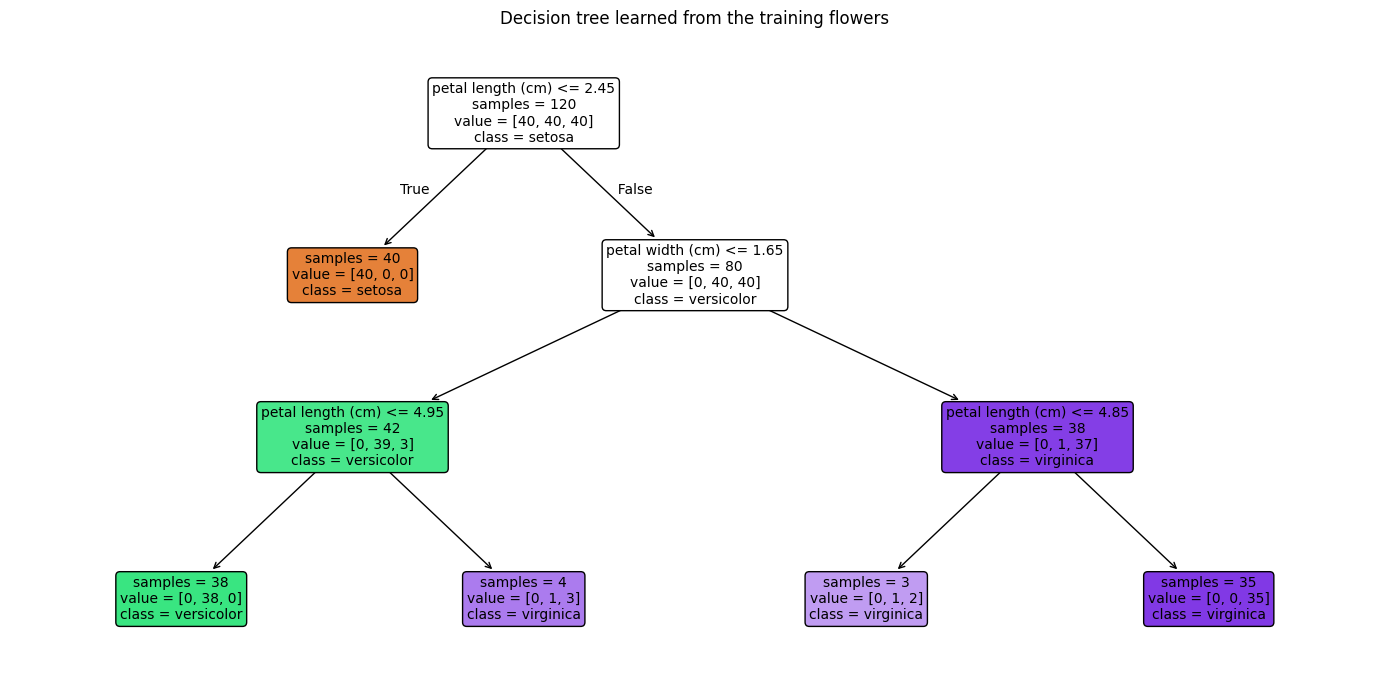

In [ ]:
print("Species order in value:", list(model.classes_))

fig, ax = plt.subplots(figsize=(14, 7))
plot_tree(
    model,
    feature_names=list(X.columns),
    class_names=list(model.classes_),
    filled=True,
    rounded=True,
    impurity=False,
    fontsize=10,
    ax=ax
)
ax.set_title("Decision tree learned from the training flowers")
fig.tight_layout()
plt.show()


### 5. Predict the labels of the test examples

`predict(X_test)` receives measurements and returns predicted species. It does not receive the test answers, `y_test`.

We can use pandas to place the measurements, actual labels, and predictions next to each other.


In [ ]:
predictions = model.predict(X_test)

results = X_test.copy()
results["actual_species"] = y_test
results["predicted_species"] = predictions
results["correct"] = results["actual_species"] == results["predicted_species"]

results.head(10)


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),actual_species,predicted_species,correct
38,4.4,3.0,1.3,0.2,setosa,setosa,True
127,6.1,3.0,4.9,1.8,virginica,virginica,True
57,4.9,2.4,3.3,1.0,versicolor,versicolor,True
93,5.0,2.3,3.3,1.0,versicolor,versicolor,True
42,4.4,3.2,1.3,0.2,setosa,setosa,True
56,6.3,3.3,4.7,1.6,versicolor,versicolor,True
22,4.6,3.6,1.0,0.2,setosa,setosa,True
20,5.4,3.4,1.7,0.2,setosa,setosa,True
147,6.5,3.0,5.2,2.0,virginica,virginica,True
84,5.4,3.0,4.5,1.5,versicolor,versicolor,True


### 6. Evaluate the predictions

**Accuracy** is the fraction of test examples predicted correctly:

`accuracy = correct predictions / total predictions`

`accuracy_score(y_test, predictions)` compares the known answers with the predictions. An accuracy of `0.90` would mean that 90% of these test examples were classified correctly.

**Question:** Why would checking the model only on the examples used for training give us weaker evidence about its behavior on new flowers?


In [ ]:
test_accuracy = accuracy_score(y_test, predictions)
number_correct = int(results["correct"].sum())

print(f"Correct predictions: {number_correct} out of {len(y_test)}")
print(f"Test accuracy: {test_accuracy:.1%}")


Correct predictions: 29 out of 30
Test accuracy: 96.7%


### Compare with a simple baseline

A **baseline** is a simple reference method. Our baseline always predicts the most frequent species in the training set and ignores all four measurements.

Comparing with this baseline helps us judge whether the learned model is doing more than applying a simple default rule. In a dataset with mostly one class, a high accuracy can be achieved by always predicting that class.

**Predict:** All three species are equally frequent here. Approximately what accuracy would you expect from always predicting one species?


In [ ]:
baseline = DummyClassifier(strategy="most_frequent")
baseline.fit(X_train, y_train)
baseline_predictions = baseline.predict(X_test)
baseline_accuracy = accuracy_score(y_test, baseline_predictions)

print(f"Baseline test accuracy: {baseline_accuracy:.1%}")
print(f"Decision tree test accuracy: {test_accuracy:.1%}")


Baseline test accuracy: 33.3%
Decision tree test accuracy: 96.7%


The test score describes performance on these 30 held-out flowers. A strong result on this small dataset does not establish that the model will work equally well on different populations, measurement conditions, or applications.

The test set is for final evaluation. If we repeatedly change settings to improve its score, we start selecting the model using the test answers. Model selection should use a separate validation set or cross-validation within the training data.


### 7. Use the trained model on new measurements

Once the model is trained, we can provide new inputs without retraining it. This prediction stage is also called **inference**.

The new data must contain the same feature columns, in the same order and with the same units. The measurements below are illustrative inputs; we have not supplied their true species.


In [ ]:
new_flowers = pd.DataFrame({
    "sepal length (cm)": [5.1, 6.0, 6.7],
    "sepal width (cm)": [3.5, 2.9, 3.0],
    "petal length (cm)": [1.4, 4.5, 5.5],
    "petal width (cm)": [0.2, 1.5, 2.1]
})

new_predictions = model.predict(new_flowers)

new_results = new_flowers.copy()
new_results["predicted_species"] = new_predictions
new_results


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),predicted_species
0,5.1,3.5,1.4,0.2,setosa
1,6.0,2.9,4.5,1.5,versicolor
2,6.7,3.0,5.5,2.1,virginica


**Discussion:** Can we calculate accuracy for these three inputs from their predictions alone? What information is missing?

A returned prediction is not proof that the predicted label is correct. To calculate accuracy, we also need the actual species.


### Short exercise: inspect and validate

1. Use the `correct` column to select the misclassified rows in `results`.
2. Print how many mistakes the model made. Check that this matches the reported number of correct predictions.
3. Add one new flower to your own DataFrame using the same four feature columns. Call `model.predict()` and print the predicted species.

Keep the trained model and test split unchanged for this exercise.

If you use AI assistance, ask it to explain the feature columns, the target, and the role of the test set before generating changes.


In [ ]:
# Select the incorrect rows and count the mistakes here.
# Then create a DataFrame for one additional flower and predict its species.


### **Code review**: what is wrong with this evaluation?

The following code is shown for discussion. Do not execute it or replace the correct evaluation above.

```python
model.fit(X, y)
predictions = model.predict(X)
print(accuracy_score(y, predictions))
```

**Question:** Does this score measure performance on examples excluded from training? Explain which data is used for each step.

**Optional AI activity:** Ask an assistant to explain the issue and propose a correction. Verify that its corrected training call uses only `X_train` and `y_train`, and that evaluation uses `X_test` and `y_test`.


### Moving this workflow to VS Code

The imports and example code can be placed in `ml_demo.py` in the same order. Use `print(results.head(10))` and `print(new_results)` for the DataFrames, since a script does not automatically display the last expression of a cell.

Install the packages in the Python environment selected by VS Code. Use the terminal installation command rather than copying `%pip` into the script. The built-in dataset works locally as well.

The important library operations are:

| Operation | Purpose |
|---|---|
| `train_test_split(...)` | Separate training examples from test examples |
| `model.fit(X_train, y_train)` | Train the model |
| `model.predict(inputs)` | Produce predictions using the trained model |
| `accuracy_score(actual, predicted)` | Compare predictions with known answers |


---

---

## Using a pretrained vision model

In the previous section we trained a small model ourselves. In the next demonstration, we will use an already trained object detector to identify objects in an image. We will still need to prepare the input, inspect the output, and check whether the result makes sense.

### Count people in a picture with YOLO

YOLO stands for **You Only Look Once**. It is a family of models for object detection: locating objects in an image and assigning labels to them. Each detection has a **bounding box** and a **confidence score**.

We will use the small, pretrained **YOLO11 nano** model. We do not train it in this demonstration. Our task is to supply an image, keep the detections labelled `person`, and count them.

**Workflow:** load the model → provide a picture → detect people → count the boxes → inspect the result.


### 1. Install the library and load the model

Run the installation cell once in your notebook environment. The first model-loading call downloads the pretrained weights, so it needs an internet connection. This short image example can run on a CPU; a GPU is optional.

Before the lesson, run these cells once to check that the packages, weights, and example image download successfully.


In [2]:
%pip install --quiet ultralytics matplotlib


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.9/46.9 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 27.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.1/58.1 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 96.0/96.0 kB 6.8 MB/s eta 0:00:00


In [3]:
from ultralytics import YOLO
from pathlib import Path
import cv2
import matplotlib.pyplot as plt

vision_model = YOLO("yolo11n.pt")

# In this pretrained model, class 0 is "person".
person_class_id = 0
print("Class to count:", vision_model.names[person_class_id])


Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/usage/settings.
Class to count: person


### 2. Choose a picture

The default is an example street photograph provided by Ultralytics. To try your own picture, upload it to Colab using the **Files** panel and name it `people.jpg`. The code uses that file when it exists. In a local notebook, place it in the notebook's working directory.


In [4]:
local_picture = Path("people.jpg")
image_source = (
    str(local_picture)
    if local_picture.exists()
    else "https://ultralytics.com/images/bus.jpg"
)
print("Image source:", image_source)


Image source: https://ultralytics.com/images/bus.jpg


### 3. Detect and count people

`predict()` returns one result for each input image. We have supplied one picture, so we use the first result, at index `0`.

`classes=[person_class_id]` keeps only person detections. `conf=0.35` sets the minimum confidence score: detections below that threshold are discarded. Since our result contains only people, the number of boxes is our estimated count.


In [5]:
confidence_threshold = 0.35

image_predictions = vision_model.predict(
    source=image_source,
    classes=[person_class_id],
    conf=confidence_threshold,
    verbose=False
)

image_result = image_predictions[0]
people_count = len(image_result.boxes)
print(f"Detected people: {people_count}")


Detected people: 4


### 4. Inspect the picture

`plot()` draws the detection boxes and labels. Its image uses OpenCV's BGR colour order; we convert it to RGB for Matplotlib.


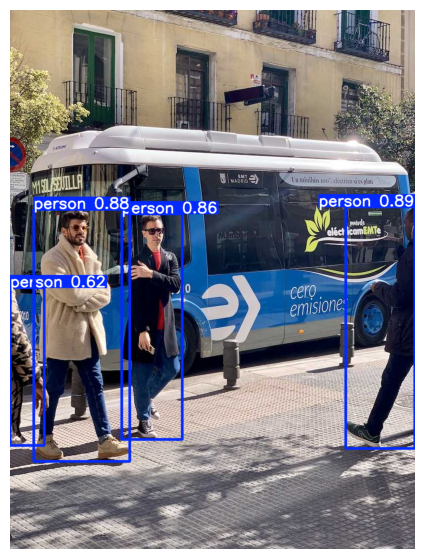

In [6]:
annotated_image = image_result.plot()

plt.figure(figsize=(10, 7))
plt.imshow(cv2.cvtColor(annotated_image, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()


**Check the result:** Count the visible people yourself and compare that number with the model's output. Has it missed anyone or drawn a box around something that is not a person?

This is a count of **detections**, not a guaranteed count of the people actually present. Small, partially hidden, or blurred people may be missed. A confidence score is not a guarantee that a box is correct.

**Quick experiment:** Change `confidence_threshold` to `0.60`, rerun the prediction and display cells, and compare the boxes and count. A higher threshold can remove incorrect detections, but it can also remove correct ones.


### Exercise: extend the example with AI assistance

#### A. Show the count inside the picture

Ask an AI assistant to help you modify the display code so that it:

1. Writes `Detected people: N` on the annotated image, using the value of `people_count`.
2. Makes the text readable against the background, for example by drawing a solid rectangle behind it.
3. Displays the new picture and saves it as `counted_people.jpg`.

**Hint:** OpenCV provides `cv2.putText()`, `cv2.rectangle()`, and `cv2.imwrite()`. Add the text to the BGR image returned by `plot()`; convert to RGB only when displaying it with Matplotlib. Start from a fresh `image_result.plot()` each time you rerun your code.

Give the assistant the existing code and ask it to explain every added line. Check that the displayed count comes from the detections rather than being written as a fixed number.


In [ ]:
# Add the count to a fresh annotated image here.
# Display it and save it as counted_people.jpg.


#### B. Count people in live video

A video is a sequence of images called **frames**. Reuse the same detection and counting steps for each frame, including the text added in Part A. The number should describe the **current frame**. Adding counts across frames would count the same person repeatedly; counting unique visitors would require a separate tracking task.

| Where you are working | Exercise input and output |
|---|---|
| VS Code with local Python | Read a live webcam with `cv2.VideoCapture(0)` and display the annotated frames in a window. |
| Colab with its hosted runtime | Upload a short video named `people.mp4`, process it frame by frame, and save an annotated video. You can continue the exercise without installing VS Code. |

Colab runs Python on a remote machine. `cv2.VideoCapture(0)` there does not open your laptop's camera, and `cv2.imshow()` does not create a local desktop window. Live webcam input in Colab requires a separate browser capture step; treat this as an optional extension after the recorded-video version works.

**Suggested prompt for the local webcam exercise:**

> I have a working Python example that loads `YOLO("yolo11n.pt")`, detects only class 0 (`person`) with a confidence threshold of 0.35, and displays an annotated picture. Here is my code: [paste your code]. Help me create `count_people_live.py` for my local Python environment in VS Code. Load the model once before the loop. Open webcam 0 and check that it opens. Read one frame at a time, stop if reading fails, detect people, and show the boxes and `Detected people: N` on every frame, including when N is zero. Let me quit with q. Release the camera and close the windows even if an error occurs. Keep the code simple, include the terminal installation command, and explain the loop and each new OpenCV operation.

**If you are staying in Colab:** Replace the webcam and window requirements in that prompt with: read `people.mp4`, process one frame at a time without storing all frames in memory, and write `counted_people.mp4` with the source dimensions and frame rate. Check that both the video reader and writer open, release both when finished, and show the saved video in the notebook. Ask the assistant to use a browser-compatible video format for playback.


### Review the AI-generated solution

Before accepting the code, check it with frames containing zero, one, and several people:

- Does the number match the person boxes shown on that frame?
- Does it return to zero when nobody is detected?
- Is the model loaded once, and is the count recomputed for each frame?
- Does the local webcam window close and release the camera when you press q?
- For the Colab version, does the saved video play and show the count throughout?

If a check fails, describe the observed behaviour to the assistant and ask for a focused correction. You should be able to explain where each frame comes from, where inference happens, and how the count is calculated.


---

---

## Closing words:

During this course, you have moved from variables and simple operations to working with data, calling AI services, and using pretrained models. You now have a foundation for understanding how these applications work and for building small solutions of your own.

You will still encounter unfamiliar code and errors. That is a normal part of programming, including for experienced developers. What matters is learning how to investigate: break the problem into smaller steps, inspect what happens, and check whether the result makes sense.

Use AI to help you learn and build. Ask it to explain its suggestions, identify assumptions, and help you test your solution. When you use generated code, take the time to understand the important steps and verify the outputs.

My advice is to keep practicing with small problems that matter to you. Automate a repetitive task, explore a dataset, or extend one of our examples. Each small project will give you another opportunity to develop your understanding.

Thank you for your participation, your questions, and your willingness to try something new.

### Practical Reminders for the future:

- **Start small**: Get one simple version working before adding features.
- **Predict, then run**: Think about the expected output and compare it with what happens.
- **Use AI actively**: Ask for explanations and focused changes, then check them.
- **Test beyond the example**: Try empty inputs, unexpected values, and cases where you know the answer.
- **Keep practicing**: Revisit the notebooks and adapt an example to a problem of your own. Explore the resources in `useful_links.txt`